# Exercise 8

### Calculation of $|\Psi_T|^2$

Since $\Psi_T^{\mu, \sigma}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}$, its squared modulus can be calculated as

$$|\Psi_T^{\mu, \sigma}(x)|^2 \propto e^{-\frac{(x-\mu)^2}{\sigma^2}} + e^{-\frac{(x+\mu)^2}{\sigma^2}} + 2e^{-\frac{x^2+\mu^2}{\sigma^2}} = e^{-\frac{x^2+\mu^2}{\sigma^2}}\left[e^{\frac{2x\mu}{\sigma^2}} + e^{-\frac{2x\mu}{\sigma^2}} + 2\right] \propto e^{-\frac{x^2}{\sigma^2}} \cosh^2\left(\frac{x\mu}{\sigma^2}\right)$$ 
where I dropped all constant factors not depending on the position since this will be used in the acceptance ratio and all the common factors are going to drop anyway

### Calculation of the integrand

The integrand function needs the analytical calculation of

$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}
$$
where $\hbar$ and $m$ are going to be set to $1$.

The fact that it is a ratio implies that all the normalization and common factors between the derivative and the function can be dropped.

$$
\frac{\partial}{\partial x} \Psi^{\mu, \sigma}_T(x) = -\frac{1}{\sigma^2}\left[(x-\mu)e^{-\frac{(x-\mu)^2}{2\sigma^2}} + (x+\mu)e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right]
$$

$$
\frac{\partial^2}{\partial x^2} \Psi^{\mu, \sigma}_T(x) = -\frac{1}{\sigma^2}\left[e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right] + \frac{1}{\sigma^4}\left[(x-\mu)^2e^{-\frac{(x-\mu)^2}{2\sigma^2}} + (x+\mu)^2e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right] \newline
= -\frac{1}{\sigma^2}\Psi^{\mu, \sigma}_T(x) + \frac{x^2 + \mu^2}{\sigma^4}\Psi^{\mu, \sigma}_T(x) + \frac{2x\mu}{\sigma^4}\left[e^{-\frac{(x+\mu)^2}{2\sigma^2}} - e^{-\frac{(x-\mu)^2}{2\sigma^2}}\right] = \newline
-\frac{1}{\sigma^2}\Psi^{\mu, \sigma}_T(x) + \frac{x^2 + \mu^2}{\sigma^4}\Psi^{\mu, \sigma}_T(x) + \frac{2x\mu}{\sigma^4}e^{-\frac{x^2+\mu^2}{2\sigma^2}}\left[e^{-\frac{x\mu}{\sigma^2}} - e^{\frac{x\mu}{\sigma^2}}\right] 
$$

$$
\frac{{-\frac{1}{2}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)} = \frac{1}{2\sigma^2} - \frac{x^2 + \mu^2}{2\sigma^4} + \frac{x\mu}{\sigma^4} \tanh{\left(\frac{x\mu}{\sigma^2}\right)}
$$

In [43]:
import numpy as np;
from matplotlib import pyplot as plt
import scipy.integrate as integrate

### Energy evolution

In [44]:
SA_step, temperature, energy, energy_error = np.loadtxt("outputs/energy.dat", unpack=True)
SA_step, temperature, mu, sigma = np.loadtxt("outputs/mu_sigma.dat", unpack=True)

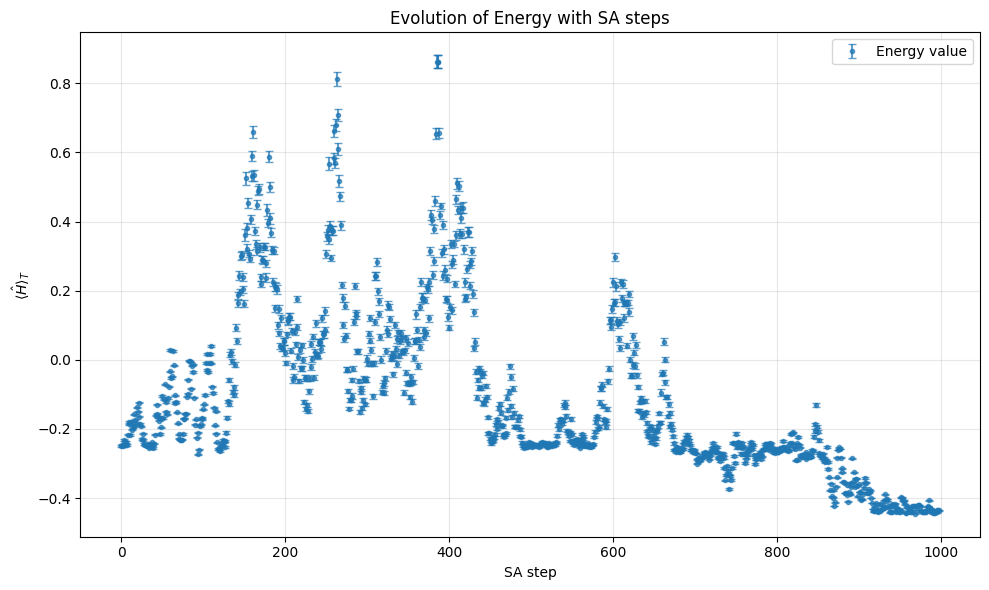

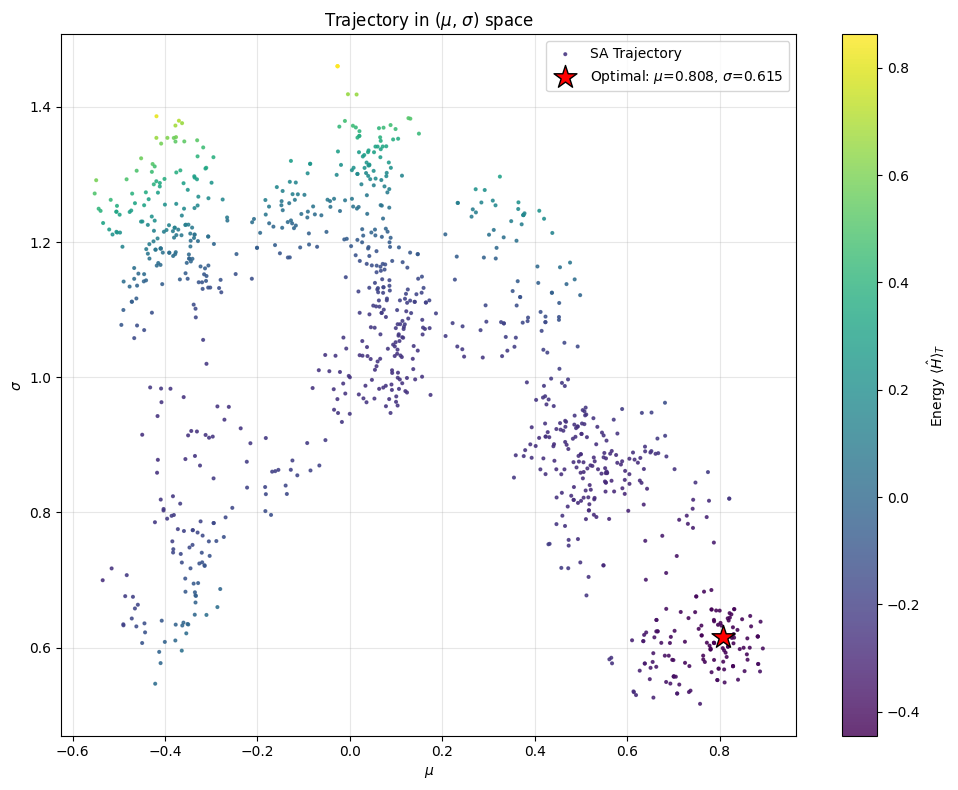

In [45]:
# =========================================================
# FIGURE 1: Energy Evolution
# =========================================================
plt.figure(figsize=(10, 6))

plt.errorbar(SA_step, energy, yerr=energy_error, fmt='.', label='Energy value', capsize=3, alpha=0.7)
plt.title('Evolution of Energy with SA steps')
plt.ylabel(r'$\langle {\hat H} \rangle_T$')
plt.xlabel('SA step')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# FIGURE 2: Trajectory in Parameter Space
# =========================================================
plt.figure(figsize=(10, 8))

sc = plt.scatter(mu, sigma, marker='.', c=energy, cmap='viridis', alpha=0.8, s=15, zorder=2, label='SA Trajectory')
cbar = plt.colorbar(sc)
cbar.set_label(r'Energy $\langle {\hat H} \rangle_T$')

# Optimal values
best_idx = np.argmin(energy)
best_mu = mu[best_idx]
best_sigma = sigma[best_idx]

plt.scatter(best_mu, best_sigma, marker='*', color='red', edgecolor='black', s=300, zorder=5, 
            label=f'Optimal: $\mu$={best_mu:.3f}, $\sigma$={best_sigma:.3f}')

plt.title("Trajectory in ($\mu$, $\sigma$) space")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Energy in function of block

In [46]:
blk, energy, error = np.loadtxt("outputs/best_energy_blocks.dat", unpack=True)

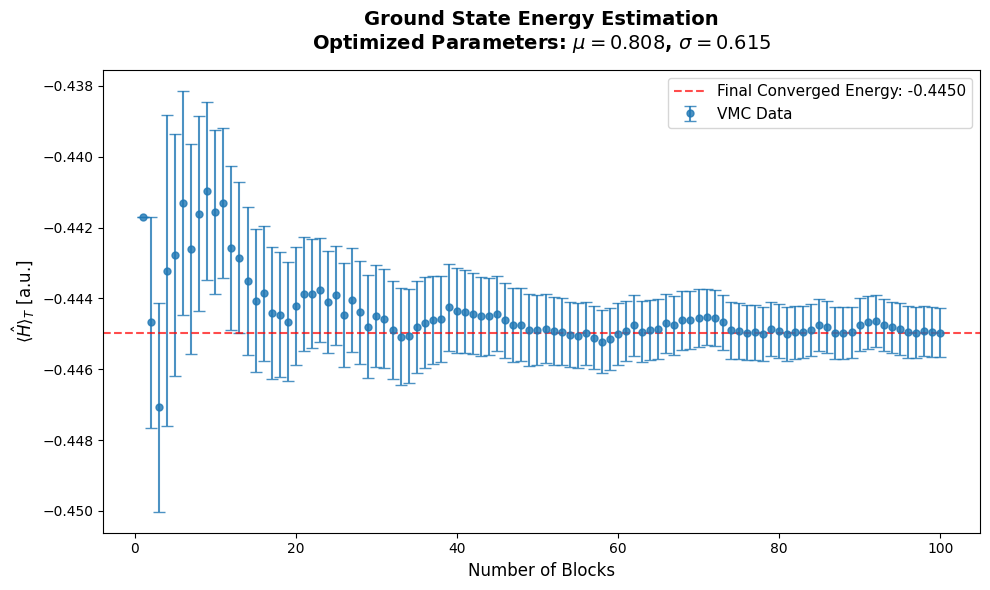

In [47]:
# =========================================================
# FIGURE 1: Energy vs. Block
# =========================================================
plt.figure(figsize=(10, 6))

plt.errorbar(x=blk, y=energy, yerr=error, fmt='o', elinewidth=1.5, capsize=4, markersize=5, 
             alpha=0.8, label=r'VMC Data')

# Horizontal line showing the final converged energy
final_energy = energy[-1]
plt.axhline(y=final_energy, color='red', linestyle='--', alpha=0.7, 
            label=f'Final Converged Energy: {final_energy:.4f}')

plt.xlabel("Number of Blocks", fontsize=12)
plt.ylabel(r"$\langle {\hat H} \rangle_T$ [a.u.]", fontsize=12)
plt.title(f"Ground State Energy Estimation\n"
          f"Optimized Parameters: $\mu={best_mu:.3f}$, $\sigma={best_sigma:.3f}$", 
          fontsize=14, fontweight='bold', pad=15)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Histogram for $|\Psi^{\mu_{best}, \sigma_{best}}_T|$

In [48]:
x_sampled = np.loadtxt("outputs/sampled_x.dat")

In [50]:
# Numerical algebraic solution to the discretized Schroedinger equation
def Vpot(x):
    return (x**2 - 2.5)*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

In [51]:
psi_ground_sq = (psi[0])**2

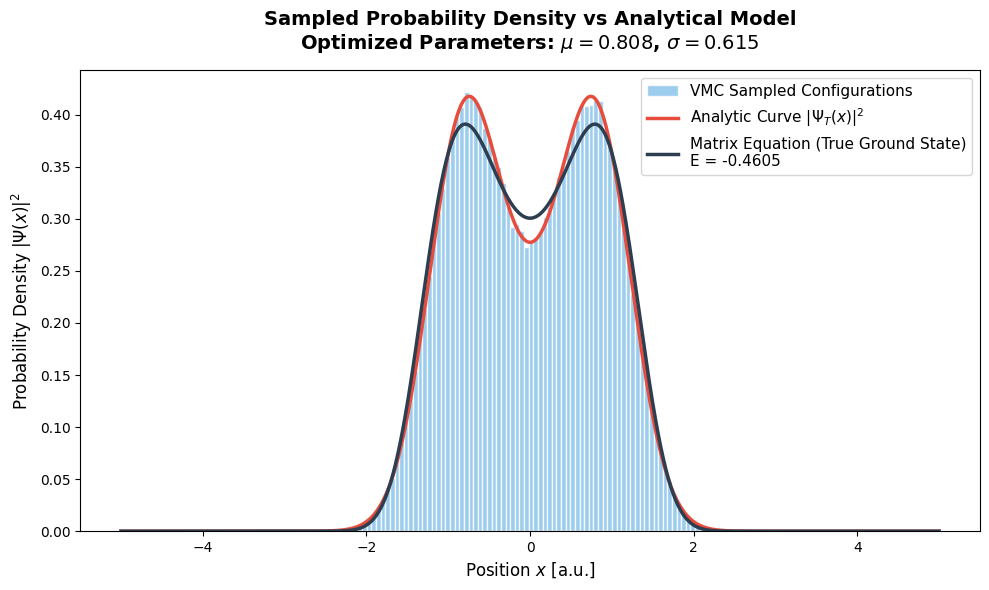

In [52]:
# =========================================================
# FIGURE 2: Sampled Wavefunction vs Analytical
# =========================================================
plt.figure(figsize=(10, 6))

plt.hist(x=x_sampled, bins=100, density=True, color='#85C1E9', edgecolor='white', 
         alpha=0.8, label='VMC Sampled Configurations')

# Overlay analytical curve
def psi_T_sq(x_val, mu, sigma):
    term1 = np.exp(-(x_val - mu)**2 / (2 * sigma**2))
    term2 = np.exp(-(x_val + mu)**2 / (2 * sigma**2))
    return (term1 + term2)**2

norm, _ = integrate.quad(psi_T_sq, -10, 10, args=(best_mu, best_sigma))

y_analytic = psi_T_sq(x, best_mu, best_sigma) / norm

plt.plot(x, y_analytic, color='#E74C3C', linewidth=2.5, 
         label=r'Analytic Curve $|\Psi_T(x)|^2$')

# Matrix Numerical Solution
plt.plot(x, psi_ground_sq, color='#2C3E50', linewidth=2.5, 
         label=f'Matrix Equation (True Ground State)\nE = {E[0]:.4f}')

plt.xlabel("Position $x$ [a.u.]", fontsize=12)
plt.ylabel(r"Probability Density $|\Psi(x)|^2$", fontsize=12)
plt.title(f"Sampled Probability Density vs Analytical Model\n"
          f"Optimized Parameters: $\mu={best_mu:.3f}$, $\sigma={best_sigma:.3f}$", 
          fontsize=14, fontweight='bold', pad=15)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()